# Data Pipeline Review

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = (
    PROJECT_ROOT
    / "metadata"
    / "data_pipeline"
)

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "data_pipeline"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

Reading data:

In [3]:
subject_stats = pd.read_csv(
    DATA_DIR
    / "chbmit_subject_channel_statistics.csv"
)

fold_scalers = pd.read_csv(
    DATA_DIR
    / "chbmit_fold_scalers.csv"
)

class_weights = pd.read_csv(
    DATA_DIR
    / "chbmit_fold_class_weights.csv"
)

fold_summary = pd.read_csv(
    DATA_DIR
    / "chbmit_fold_dataset_summary.csv"
)

# Checking the Mean Channels

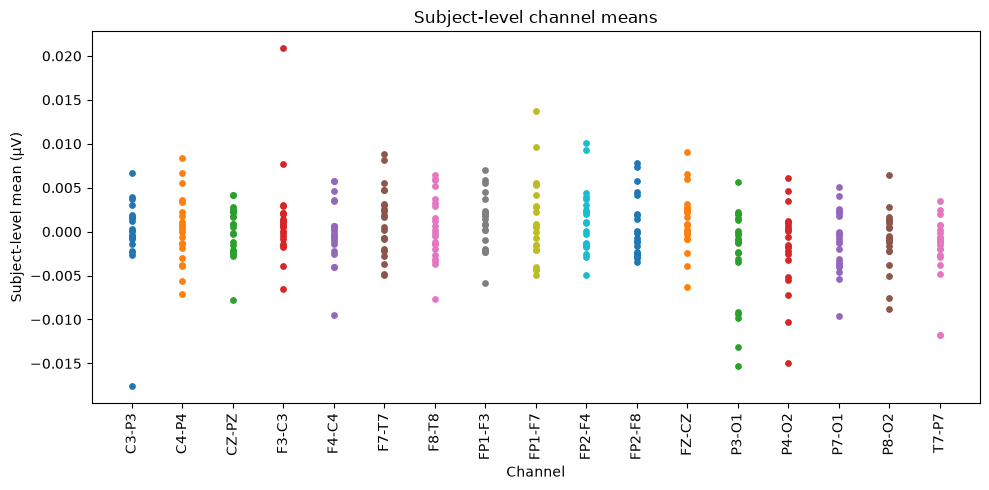

In [4]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

for channel_name, group in (
    subject_stats.groupby(
        "channel_name"
    )
):
    ax.scatter(
        [channel_name] * len(group),
        group["mean_uv"],
        s=15,
    )

ax.set_xlabel("Channel")
ax.set_ylabel("Subject-level mean (µV)")
ax.set_title(
    "Subject-level channel means"
)
ax.tick_params(
    axis="x",
    rotation=90,
)

fig.tight_layout()
fig.savefig(
    REPORT_DIR
    / "channel_mean_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Check STD channels

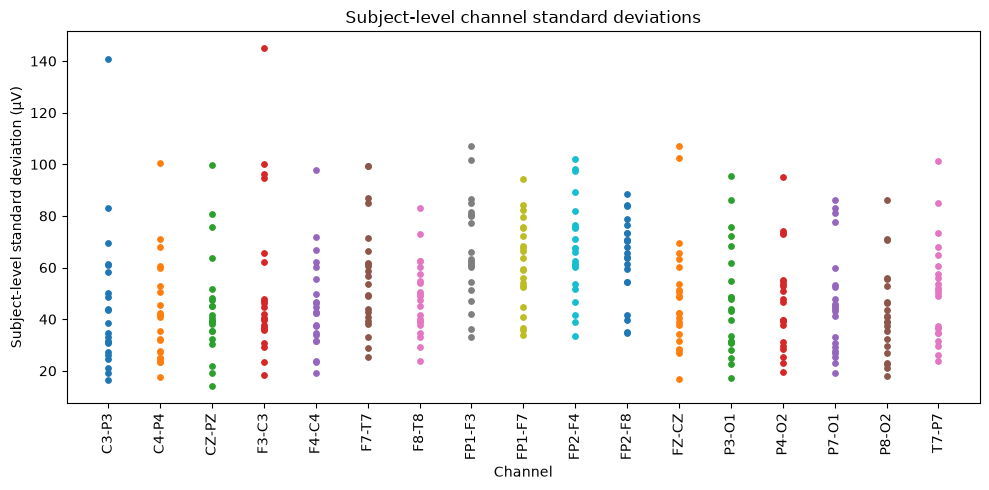

In [5]:
fig, ax = plt.subplots(
    figsize=(10, 5)
)

for channel_name, group in (
    subject_stats.groupby(
        "channel_name"
    )
):
    ax.scatter(
        [channel_name] * len(group),
        group["std_uv"],
        s=15,
    )

ax.set_xlabel("Channel")
ax.set_ylabel("Subject-level standard deviation (µV)")
ax.set_title(
    "Subject-level channel standard deviations"
)
ax.tick_params(
    axis="x",
    rotation=90,
)

fig.tight_layout()
fig.savefig(
    REPORT_DIR
    / "channel_std_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Class ratio in Train Folds

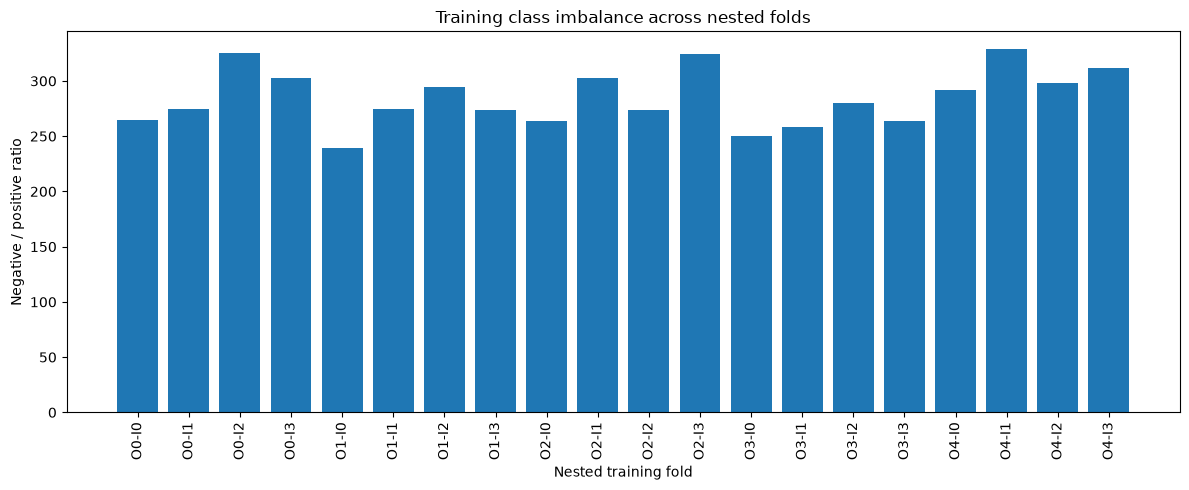

In [6]:
inner_weights = class_weights.loc[
    class_weights["scope"]
    == "inner_training"
].copy()

inner_weights["fold_name"] = (
    "O"
    + inner_weights[
        "outer_fold"
    ].astype(int).astype(str)
    + "-I"
    + inner_weights[
        "inner_fold"
    ].astype(int).astype(str)
)

fig, ax = plt.subplots(
    figsize=(12, 5)
)

ax.bar(
    inner_weights["fold_name"],
    inner_weights[
        "raw_negative_to_positive_ratio"
    ],
)

ax.set_xlabel("Nested training fold")
ax.set_ylabel("Negative / positive ratio")
ax.set_title(
    "Training class imbalance across nested folds"
)
ax.tick_params(
    axis="x",
    rotation=90,
)

fig.tight_layout()
fig.savefig(
    REPORT_DIR
    / "train_class_ratios.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()